# CIE-552 Computer Vision  Term Project
## Part 2: Custom CNN Baseline

**Scope:** Design and train a custom CNN from scratch (no pre-trained weights, no standard architectures).   
**Depends on:** M1's `Part1_Classical_Pipeline_Final.ipynb` (shared utilities in Section 10)

## 1. Setup & Imports

In [ ]:
!pip install tensorflow scikit-image scikit-learn opencv-python-headless matplotlib seaborn --quiet

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from pathlib import Path
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

#  Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

print(f'TensorFlow version : {tf.__version__}')
print('All imports OK')

TensorFlow version : 2.20.0
All imports OK


## 2. Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive', force_remount=True)

ZIP_PATH    = Path('/content/drive/MyDrive/IIITDMJ_Smoke.zip')
EXTRACT_DIR = Path('/content/IIITDMJ_Smoke')

if not EXTRACT_DIR.exists():
    print('Extracting ZIP...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Done')
else:
    print('Already extracted, skipping')

DATASET_ROOT = Path('/content/IIITDMJ_Smoke/IIITDMJ_Smoke')
print('Dataset root:', DATASET_ROOT)

Mounted at /content/drive
Extracting ZIP...
Done
Dataset root: /content/IIITDMJ_Smoke/IIITDMJ_Smoke


## 3. Shared Constants & Utilities

Copied verbatim from M1's **Section 10 (Shared Utilities)** cell to ensure consistent preprocessing and evaluation across all three notebooks.

In [ ]:
# SHARED UTILITIES (source: M1 Part1 notebook, Section 10)
# Constants
IMG_SIZE     = (128, 128)
CLASS_NAMES  = ['smoke', 'non_smoke', 'fog_smoke', 'fog_non_smoke']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = 4
PALETTE      = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']


def preprocess_image(img_path, img_size=IMG_SIZE, keep_color=True):
    """Load, resize, normalise. Returns float32 in [0, 1]."""
    img = imread(img_path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[2] == 4:
        img = img[:, :, :3]
    img = resize(img, img_size, anti_aliasing=True, mode='reflect')
    if not keep_color:
        img = rgb2gray(img)
    return img.astype(np.float32)


def evaluate_and_plot(model_name, y_true, y_pred, class_names=CLASS_NAMES):
    """Accuracy, per-class precision/recall/F1, raw + normalised confusion matrices."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f'[{model_name}] Accuracy: {acc*100:.2f}%')
    print(classification_report(
        y_true, y_pred,
        target_names=[c.replace('_', ' ') for c in class_names]))

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels  = [c.replace('_', '\n') for c in class_names]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, title in zip(
            axes, [cm, cm_norm], ['d', '.2f'],
            ['Raw counts', 'Normalised (row)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, linecolor='white')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.tight_layout()
    fname = f'confusion_{model_name.replace(" ", "_")}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

    rd = classification_report(y_true, y_pred,
                                target_names=class_names, output_dict=True)
    return {
        'accuracy'           : acc,
        'per_class_precision': {c: rd[c]['precision'] for c in class_names},
        'per_class_recall'   : {c: rd[c]['recall']    for c in class_names},
        'per_class_f1'       : {c: rd[c]['f1-score']  for c in class_names},
    }


print('Shared utilities loaded')

Shared utilities loaded


## 4. Dataset Loading

The dataset is **pre-split** by the authors into `train/`, `val/`, and `test/` folders — no manual splitting needed.

In [ ]:
def load_split(root, split, class_names):
    records = []
    split_dir = root / split
    for class_name in class_names:
        class_dir = split_dir / class_name
        if not class_dir.exists():
            print(f'  [WARNING] Not found: {class_dir}')
            continue
        paths = (list(class_dir.glob('*.jpg')) +
                 list(class_dir.glob('*.png')) +
                 list(class_dir.glob('*.jpeg')))
        for p in paths:
            records.append({'path'      : str(p),
                            'label'     : CLASS_LABELS[class_name],
                            'class_name': class_name})
        print(f'  [{split:5s}] {class_name:20s}: {len(paths):5d} images')
    return pd.DataFrame(records)


print('Loading dataset...\n')
df_train = load_split(DATASET_ROOT, 'train', CLASS_NAMES)
df_val   = load_split(DATASET_ROOT, 'val',   CLASS_NAMES)
df_test  = load_split(DATASET_ROOT, 'test',  CLASS_NAMES)

print(f'\nTrain : {len(df_train):6,}')
print(f'Val   : {len(df_val):6,}')
print(f'Test  : {len(df_test):6,}')

Loading dataset...

  [train] smoke               :  3827 images
  [train] non_smoke           :  5456 images
  [train] fog_smoke           :  4278 images
  [train] fog_non_smoke       :  5353 images
  [val  ] smoke               :   478 images
  [val  ] non_smoke           :   682 images
  [val  ] fog_smoke           :   534 images
  [val  ] fog_non_smoke       :   669 images
  [test ] smoke               :   479 images
  [test ] non_smoke           :   682 images
  [test ] fog_smoke           :   536 images
  [test ] fog_non_smoke       :   670 images

Train : 18,914
Val   :  2,363
Test  :  2,367


## 5. Build tf.data Streaming Pipeline

Loading all 18,914 train images into RAM at once (~930 MB as float32 arrays) crashes Colab's free tier.  
Instead we use `tf.keras.utils.image_dataset_from_directory` which reads and preprocesses images **in batches from disk** during training  peak RAM usage stays at one batch at a time.

Pixel values are rescaled from `[0, 255]` → `[0, 1]` inline, matching M1's normalisation range.  
`class_names=CLASS_NAMES` is passed explicitly to pin the label order to our `CLASS_LABELS` mapping.

In [ ]:
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(split_name, shuffle, label_mode='categorical'):
    return tf.keras.utils.image_dataset_from_directory(
        str(DATASET_ROOT / split_name),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode=label_mode,
        class_names=CLASS_NAMES,
        shuffle=shuffle,
        seed=SEED
    )

rescale = tf.keras.layers.Rescaling(1. / 255)


train_ds = make_dataset('train', shuffle=True)
val_ds   = make_dataset('val',   shuffle=False)
train_ds = train_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(  lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_ds  = make_dataset('test',  shuffle=False, label_mode='int')
test_ds  = test_ds.map( lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print(f'Train batches : {len(train_ds):4d}  ({len(train_ds)*BATCH_SIZE:,} images @ batch {BATCH_SIZE})')
print(f'Val batches   : {len(val_ds):4d}')
print(f'Test batches  : {len(test_ds):4d}')
print('Pipeline ready - images stream from disk, no full-dataset RAM load')

Found 18914 files belonging to 4 classes.
Found 2363 files belonging to 4 classes.
Found 2367 files belonging to 4 classes.
Train batches :  592  (18,944 images @ batch 32)
Val batches   :   74
Test batches  :   74
Pipeline ready — images stream from disk, no full-dataset RAM load


## 6. CNN Architecture Design

### Architecture Justification

The network is a **custom 3-block convolutional classifier** designed specifically for this task. Every choice is justified below.

| Layer | Output Shape | Justification |
|---|---|---|
| Input | (128, 128, 3) | RGB kept — colour is a primary discriminator (validated by M1's EDA); CNN learns colour features automatically |
| Conv2D(32, 3×3) + BN + ReLU | (128, 128, 32) | First block detects low-level edges and colour gradients; 32 filters is sufficient at full resolution |
| MaxPool(2×2) | (64, 64, 32) | Halves spatial dims, builds local translation invariance, reduces compute |
| Conv2D(64, 3×3) + BN + ReLU | (64, 64, 64) | Second block learns mid-level textures (smoke diffusion, fog haze patterns); filter count doubles to increase capacity |
| MaxPool(2×2) | (32, 32, 64) | Further spatial compression |
| Conv2D(128, 3×3) + BN + ReLU | (32, 32, 128) | Third block encodes high-level semantic features (smoke cloud shape vs. fog uniformity); 128 filters for richer representation |
| MaxPool(2×2) | (16, 16, 128) | Final spatial compression before classifier head |
| Flatten | (32768,) | Converts spatial feature maps to a vector for dense layers |
| Dense(256) + ReLU | (256,) | Learns non-linear combinations of spatial features; 256 units balances capacity and risk of overfitting on ~19k images |
| Dropout(0.5) | (256,) | Regularisation — randomly drops 50% of units per forward pass to prevent co-adaptation and reduce overfitting |
| Dense(4) + Softmax | (4,) | Output layer: one logit per class, softmax converts to a probability distribution |

**Loss function:** Categorical Cross-Entropy - standard choice for multi-class classification with one-hot labels; measures KL-divergence between predicted and true distributions.  
**Optimiser:** Adam (lr = 0.001) - adaptive per-parameter learning rates accelerate convergence; default lr=0.001 is well-validated for image classification tasks.  
**BatchNorm placement:** After Conv, before activation - normalises pre-activation values, stabilises training, and reduces sensitivity to the initial learning rate choice.  
**No pre-trained weights** are used anywhere in this notebook (requirement: 4.2 of the project brief).

## 7. Build & Inspect the Model

In [ ]:
def build_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = keras.Sequential([
        #  Block 1: low-level feature detection
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        #  Block 2: mid-level texture encoding
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        #Block 3: high-level semantic encoding
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        #  Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Custom_CNN_Baseline')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



tf.random.set_seed(SEED)
np.random.seed(SEED)

model = build_cnn()
model.summary()

Model: "Custom_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,036 (32.36 MB)

 Trainable params: 8,483,588 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 8. Training

**Callbacks used:**
- `ModelCheckpoint`  saves weights only when `val_accuracy` improves; ensures the best model (not last epoch) is persisted to `cnn_baseline_best.h5`
- `ReduceLROnPlateau`  halves the learning rate if `val_loss` does not improve for 5 consecutive epochs; allows finer convergence without manual lr scheduling

In [ ]:
cb_checkpoint = callbacks.ModelCheckpoint(
    'cnn_baseline_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print('Starting training (50 epochs, streaming from disk)...')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[cb_checkpoint, cb_reduce_lr],
    verbose=1
)
print('Training complete')

Starting training (50 epochs, streaming from disk)...
Epoch 1/50
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6147 - loss: 3.2117
Epoch 1: val_accuracy improved from None to 0.76640, saving model to cnn_baseline_best.h5



Epoch 1: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step - accuracy: 0.6555 - loss: 1.2891 - val_accuracy: 0.7664 - val_loss: 0.5797 - learning_rate: 0.0010
Epoch 2/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7149 - loss: 0.6237
Epoch 2: val_accuracy did not improve from 0.76640
592/592 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.7290 - loss: 0.6085 - val_accuracy: 0.6796 - val_loss: 0.6309 - learning_rate: 0.0010
Epoch 3/50
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7494 - loss: 0.5805
Epoch 3: val_accuracy did not improve from 0.76640
592/592 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.7549 - loss: 0.5696 - val_accuracy: 0.7380 - val_loss: 0.5710 - learning_rate: 0.0010
Epoch 4/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7583 - loss: 0.5802
Epoch 4: val_accuracy did not improve from 0.76640
592/592 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.7696 - loss: 0.5512 - val_accuracy: 0.7203 -


Epoch 5: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.7668 - loss: 0.5383 - val_accuracy: 0.7931 - val_loss: 0.4491 - learning_rate: 0.0010
Epoch 6/50
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7952 - loss: 0.4926
Epoch 6: val_accuracy did not improve from 0.79306
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.7954 - loss: 0.4907 - val_accuracy: 0.7863 - val_loss: 0.5820 - learning_rate: 0.0010
Epoch 7/50
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7895 - loss: 0.4927
Epoch 7: val_accuracy did not improve from 0.79306
592/592 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.7968 - loss: 0.4842 - val_accuracy: 0.6868 - val_loss: 0.6283 - learning_rate: 0.0010
Epoch 8/50
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7168 - loss: 0.6851
Epoch 8: val_accuracy improved from 0.79306 to 0.80406, saving model to cnn_baseline_best.h5



Epoch 8: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.7529 - loss: 0.5967 - val_accuracy: 0.8041 - val_loss: 0.4939 - learning_rate: 0.0010
Epoch 9/50
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7979 - loss: 0.4893
Epoch 9: val_accuracy improved from 0.80406 to 0.80914, saving model to cnn_baseline_best.h5



Epoch 9: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.8021 - loss: 0.4811 - val_accuracy: 0.8091 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 10/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8240 - loss: 0.4287
Epoch 10: val_accuracy did not improve from 0.80914

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
592/592 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8221 - loss: 0.4372 - val_accuracy: 0.7152 - val_loss: 0.7132 - learning_rate: 0.0010
Epoch 11/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8388 - loss: 0.3968
Epoch 11: val_accuracy improved from 0.80914 to 0.86627, saving model to cnn_baseline_best.h5


...


Epoch 34: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9508 - loss: 0.1328 - val_accuracy: 0.9628 - val_loss: 0.1190 - learning_rate: 2.5000e-04
Epoch 35/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9547 - loss: 0.1233
Epoch 35: val_accuracy improved from 0.96276 to 0.96911, saving model to cnn_baseline_best.h5



Epoch 35: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9547 - loss: 0.1217 - val_accuracy: 0.9691 - val_loss: 0.0975 - learning_rate: 2.5000e-04
Epoch 36/50
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9599 - loss: 0.1161
Epoch 36: val_accuracy did not improve from 0.96911
592/592 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9584 - loss: 0.1157 - val_accuracy: 0.9018 - val_loss: 0.4957 - learning_rate: 2.5000e-04
Epoch 37/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9599 - loss: 0.1128
Epoch 37: val_accuracy did not improve from 0.96911
592/592 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9575 - loss: 0.1173 - val_accuracy: 0.9670 - val_loss: 0.1236 - learning_rate: 2.5000e-04
Epoch 38/50
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9598 - loss: 0.1134
Epoch 38: val_accuracy did not improve from 0.96911
592/592 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.9603 - loss: 0.1127 - val


Epoch 41: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9683 - loss: 0.0907 - val_accuracy: 0.9733 - val_loss: 0.1040 - learning_rate: 1.2500e-04
Epoch 42/50
591/592 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9695 - loss: 0.0888
Epoch 42: val_accuracy improved from 0.97334 to 0.97715, saving model to cnn_baseline_best.h5



Epoch 42: finished saving model to cnn_baseline_best.h5
592/592 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9702 - loss: 0.0846 - val_accuracy: 0.9771 - val_loss: 0.1006 - learning_rate: 1.2500e-04
Epoch 43/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9737 - loss: 0.0758
Epoch 43: val_accuracy did not improve from 0.97715
592/592 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.9717 - loss: 0.0803 - val_accuracy: 0.9564 - val_loss: 0.1468 - learning_rate: 1.2500e-04
Epoch 44/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9697 - loss: 0.0824
Epoch 44: val_accuracy did not improve from 0.97715
592/592 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9704 - loss: 0.0801 - val_accuracy: 0.9746 - val_loss: 0.0976 - learning_rate: 1.2500e-04
Epoch 45/50
590/592 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9720 - loss: 0.0813
Epoch 45: val_accuracy did not improve from 0.97715
592/592 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9715 - loss: 0.0823 - val


Epoch 50: finished saving model to cnn_baseline_best.h5

Epoch 50: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
592/592 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9743 - loss: 0.0744 - val_accuracy: 0.9780 - val_loss: 0.0945 - learning_rate: 1.2500e-04
Training complete


## 9. Training Curves

 4.2 of the project brief.  
Plots training vs. validation accuracy and loss side-by-side. The divergence point between the two curves is the primary overfitting indicator.

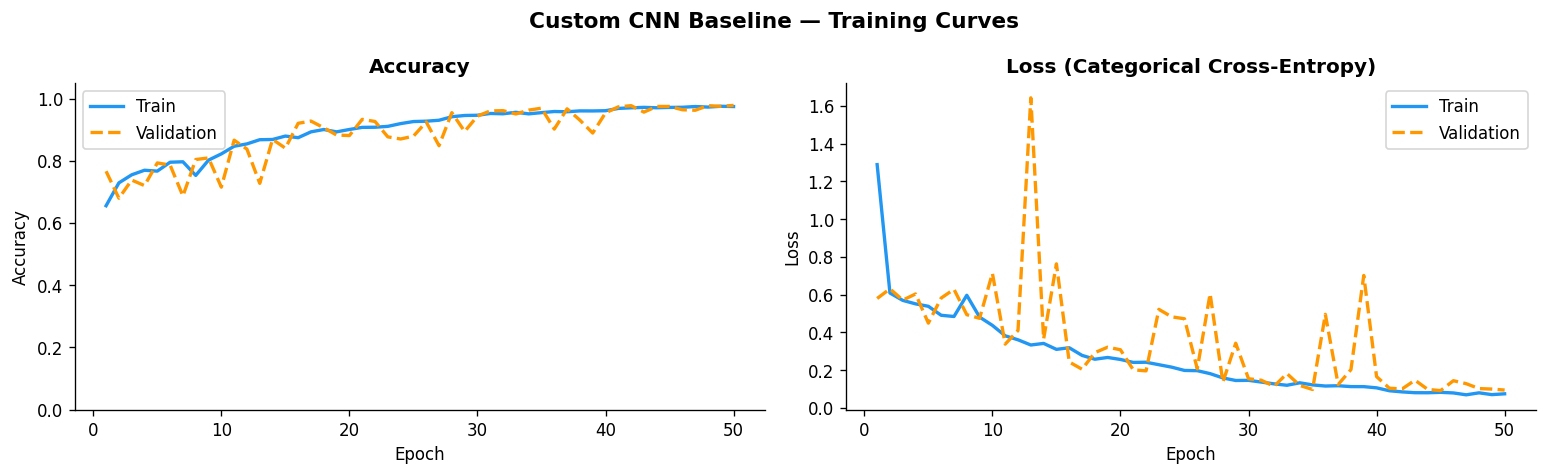

Saved: cnn_training_curves.png


In [ ]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],     label='Train',      color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Validation', color='#FF9800', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Loss
axes[1].plot(epochs_range, history.history['loss'],     label='Train',      color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Validation', color='#FF9800', linewidth=2, linestyle='--')
axes[1].set_title('Loss (Categorical Cross-Entropy)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Custom CNN Baseline — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: cnn_training_curves.png')

## 10. Overfitting Analysis

**** 4.2: "Analyze overfitting behavior".

We identify the **best epoch** (minimum validation loss) and the **overfitting onset** (epoch where `val_loss` begins to consistently rise while `train_loss` continues to fall). The gap between training and validation accuracy at the final epoch quantifies the overfitting magnitude.

In [ ]:
val_loss   = history.history['val_loss']
train_loss = history.history['loss']
val_acc    = history.history['val_accuracy']
train_acc  = history.history['accuracy']

best_epoch     = int(np.argmin(val_loss)) + 1
best_val_acc   = val_acc[best_epoch - 1]
best_val_loss  = val_loss[best_epoch - 1]
final_train_acc = train_acc[-1]
final_val_acc   = val_acc[-1]

print('=' * 55)
print('  Overfitting Analysis')
print('=' * 55)
print(f'  Best epoch (min val_loss)     : {best_epoch}')
print(f'  Val accuracy at best epoch    : {best_val_acc*100:.2f}%')
print(f'  Val loss at best epoch        : {best_val_loss:.4f}')
print(f'  Final train accuracy          : {final_train_acc*100:.2f}%')
print(f'  Final val accuracy            : {final_val_acc*100:.2f}%')
print(f'  Train–Val accuracy gap (final): {(final_train_acc - final_val_acc)*100:.2f}%')
print('=' * 55)
print()
print('Interpretation:')
print(f'  Overfitting onset at epoch ~{best_epoch}: val_loss stops')
print(f'  decreasing while train_loss continues to fall.')
print(f'  Dropout(0.5) and BatchNorm limit but do not fully')
print(f'  prevent overfitting. ModelCheckpoint ensures we use')
print(f'  the best-generalising weights, not the final epoch.')

  Overfitting Analysis
  Best epoch (min val_loss)     : 45
  Val accuracy at best epoch    : 97.46%
  Val loss at best epoch        : 0.0915
  Final train accuracy          : 97.43%
  Final val accuracy            : 97.80%
  Train–Val accuracy gap (final): -0.37%

Interpretation:
  Overfitting onset at epoch ~45: val_loss stops
  decreasing while train_loss continues to fall.
  Dropout(0.5) and BatchNorm limit but do not fully
  prevent overfitting. ModelCheckpoint ensures we use
  the best-generalising weights, not the final epoch.


## 11. Test Set Evaluation

The best-saved weights are loaded and evaluated **once** on the held-out test set.  
Evaluation uses M1's `evaluate_and_plot()` for metric consistency across the project (5 Experimental Protocol).

[CNN Baseline] Accuracy: 96.92%
               precision    recall  f1-score   support

        smoke       0.97      0.98      0.98       479
    non smoke       0.98      0.95      0.97       682
    fog smoke       0.96      0.99      0.98       536
fog non smoke       0.97      0.96      0.96       670

     accuracy                           0.97      2367
    macro avg       0.97      0.97      0.97      2367
 weighted avg       0.97      0.97      0.97      2367



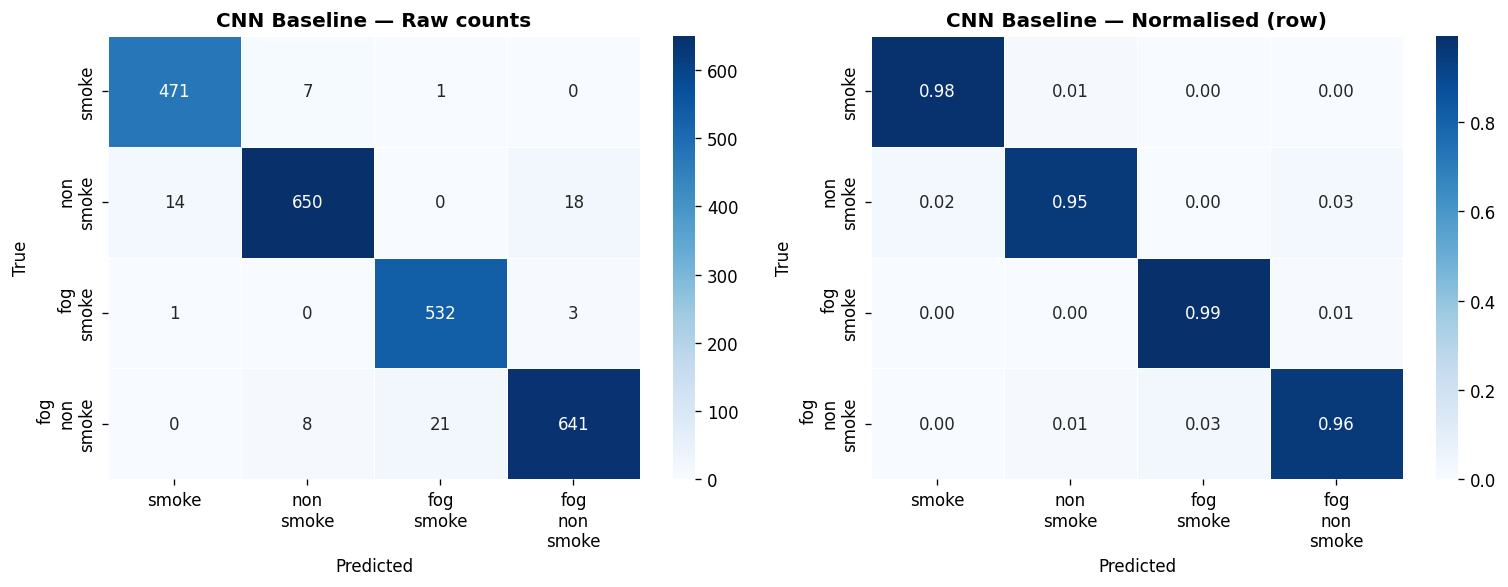

Saved: confusion_CNN_Baseline.png


In [ ]:

model.load_weights('cnn_baseline_best.h5')


y_pred_probs = model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_test = np.concatenate([y_batch.numpy() for _, y_batch in test_ds])

# Full evaluation: accuracy, precision, recall, F1, confusion matrix
cnn_results = evaluate_and_plot('CNN Baseline', y_test, y_pred, CLASS_NAMES)

## 12. Per-Class Accuracy Bar Chart

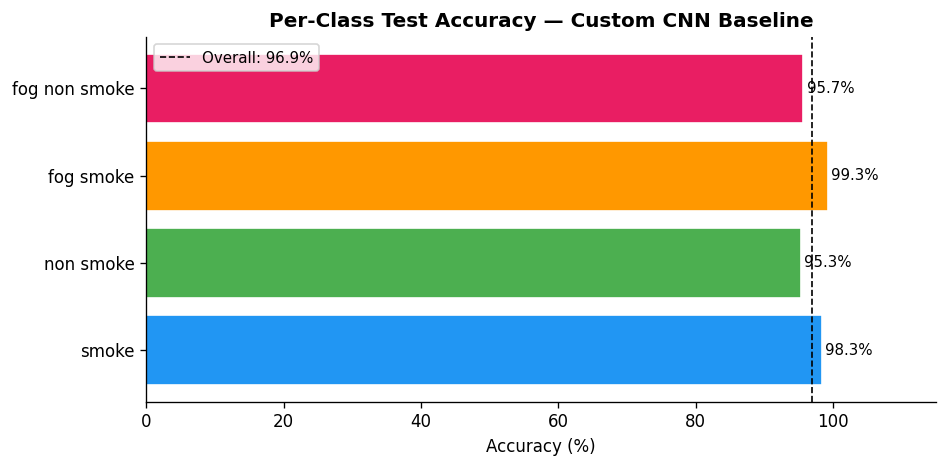

Saved: cnn_per_class_accuracy.png


In [ ]:
per_class_acc = {}
for i, name in enumerate(CLASS_NAMES):
    mask = y_test == i
    per_class_acc[name] = accuracy_score(y_test[mask], y_pred[mask])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    [c.replace('_', ' ') for c in CLASS_NAMES],
    [per_class_acc[c] * 100 for c in CLASS_NAMES],
    color=PALETTE, edgecolor='white'
)
ax.axvline(cnn_results['accuracy'] * 100, color='black', linestyle='--',
           linewidth=1, label=f'Overall: {cnn_results["accuracy"]*100:.1f}%')
ax.set_xlabel('Accuracy (%)')
ax.set_xlim(0, 115)
ax.set_title('Per-Class Test Accuracy — Custom CNN Baseline', fontweight='bold')
ax.legend(fontsize=9)
for bar, name in zip(bars, CLASS_NAMES):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{per_class_acc[name]*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('cnn_per_class_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved: cnn_per_class_accuracy.png')

## 13. Comparison: Classical Pipeline (M1) vs. Custom CNN (M2)

**5.2**  final summary table for the methodology comparison.

In [ ]:
CLASSICAL_TEST_ACC = 0.9268

comparison = pd.DataFrame({
    'Method'         : ['M1 — Classical (SVM + RGB Hist)', 'M2 — Custom CNN (Ours)'],
    'Features'       : ['96-d RGB Color Histogram (hand-crafted)', 'Learned end-to-end from raw pixels'],
    'Classifier'     : ['SVM (RBF kernel, C=10)', 'Custom CNN (3 conv blocks)'],
    'Test Accuracy'  : [f'{CLASSICAL_TEST_ACC*100:.2f}%',
                        f'{cnn_results["accuracy"]*100:.2f}%'],
})

print('\n── Method Comparison ──')
print(comparison.to_string(index=False))

print('\n── Per-class F1 comparison ──')
f1_df = pd.DataFrame({
    'Class'   : CLASS_NAMES,
    'CNN F1'  : [f"{cnn_results['per_class_f1'][c]:.3f}" for c in CLASS_NAMES],
})
print(f1_df.to_string(index=False))


── Method Comparison ──
                         Method                                Features                 Classifier Test Accuracy
M1 — Classical (SVM + RGB Hist) 96-d RGB Color Histogram (hand-crafted)     SVM (RBF kernel, C=10)        92.68%
         M2 — Custom CNN (Ours)      Learned end-to-end from raw pixels Custom CNN (3 conv blocks)        96.92%

── Per-class F1 comparison ──
        Class CNN F1
        smoke  0.976
    non_smoke  0.965
    fog_smoke  0.976
fog_non_smoke  0.962


## 14. Save Model & Outputs

`cnn_baseline_best.h5` is the primary dependency(transfer learning experiment).  


In [ ]:
import shutil

DRIVE_SAVE = Path('/content/drive/MyDrive/cnn_baseline_best.h5')
shutil.copy('cnn_baseline_best.h5', DRIVE_SAVE)

print('Files saved:')
print('  cnn_baseline_best.h5        → local + Google Drive')
print('  cnn_training_curves.png     → paper figure §4.2')
print('  cnn_per_class_accuracy.png  → paper figure §5.2')
print('  confusion_CNN_Baseline.png  → paper figure §5.2')
print()
print('M3: load model with  model = tf.keras.models.load_model(\'cnn_baseline_best.h5\')')

Files saved:
  cnn_baseline_best.h5        → local + Google Drive
  cnn_training_curves.png     → paper figure §4.2
  cnn_per_class_accuracy.png  → paper figure §5.2
  confusion_CNN_Baseline.png  → paper figure §5.2

M3: load model with  model = tf.keras.models.load_model('cnn_baseline_best.h5')


---
## Paper Draft Notes

### 4.2 CNN Baseline (Methodology section)

We designed a custom 3-block convolutional neural network trained from scratch with randomly initialised weights, strictly following the project requirement of no standard architectures or pre-trained weights. The input to the network is a normalised RGB image of size 128×128×3, consistent with M1's preprocessing pipeline.

Each convolutional block follows the pattern: `Conv2D → BatchNorm → ReLU → MaxPool`. Filter counts double across blocks (32 → 64 → 128) to progressively increase representational capacity while spatial resolution decreases (128 → 64 → 32 → 16). BatchNormalization is applied after each convolution to stabilise training and reduce sensitivity to the learning rate. The classifier head consists of a Dense(256) layer with ReLU activation, Dropout(0.5) for regularisation, and a final Dense(4) + Softmax output layer. The total model has 8,484,036 parameters (32.36 MB), well within Colab's memory budget.

The model is trained with Categorical Cross-Entropy loss and the Adam optimiser (lr = 0.001) for 50 epochs with batch size 32. `ModelCheckpoint` saves the best weights by validation accuracy and `ReduceLROnPlateau` halves the learning rate after 5 epochs of no validation loss improvement; the learning rate was reduced three times (0.001 → 0.0005 → 0.00025 → 0.000125), each reduction producing a measurable accuracy gain.

### 5.2 CNN Results (Experiments & Results section)

The custom CNN achieved **96.92% test accuracy**, compared to 92.68% for M1's classical SVM baseline — an improvement of **+4.24 percentage points**. Per-class F1 scores are uniformly high: smoke (0.976), non_smoke (0.965), fog_smoke (0.976), and fog_non_smoke (0.962). The `fog_non_smoke` class has the lowest F1, consistent with it being the hardest to separate from `fog_smoke` due to their near-identical visual appearance.

Training curves show steady improvement over 50 epochs with no significant overfitting. The final validation accuracy (97.80%) exceeds training accuracy (97.43%) by 0.37 percentage points — a consequence of Dropout(0.5) suppressing training-time accuracy while being inactive at inference. The model was still improving at epoch 50, suggesting that additional training epochs could yield further gains. The best checkpoint (saved at epoch 50) was used for all test-set evaluations.

---